In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
df = pd.read_csv(
    "../data/raw/bank-full.csv",
    sep=";"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [8]:
print("Number of observations:", df.shape[0])
print("Number of attributes:", df.shape[1])

Number of observations: 45211
Number of attributes: 17


In [9]:
print(df.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [11]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [12]:
# Display dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types and non-null counts
print("\nDataset Information:")
df.info()

Number of rows: 45211
Number of columns: 17

Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  p

In [13]:
# Identify numerical features
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical features
categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nTotal Numerical Features:", len(numerical_features))
print("Total Categorical Features:", len(categorical_features))

Numerical Features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Total Numerical Features: 7
Total Categorical Features: 10


C:\Users\jayen\AppData\Local\Temp\ipykernel_43108\2601050614.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


In [15]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [16]:
# Count missing values
missing_count = df.isnull().sum()

# Calculate percentage
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

# Combine results
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

display(missing_summary)

,Missing Count,Missing Percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


In [17]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

# Calculate percentage
duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print("Duplicate Percentage:", round(duplicate_percentage, 2), "%")

Number of duplicate records: 0
Duplicate Percentage: 0.0 %


In [18]:
# Count target classes
target_counts = df["y"].value_counts()

print(target_counts)

# Calculate percentages
target_percentage = df["y"].value_counts(normalize=True) * 100

print("\nTarget Class Percentages:")
print(target_percentage.round(2))

y
no     39922
yes     5289
Name: count, dtype: int64

Target Class Percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


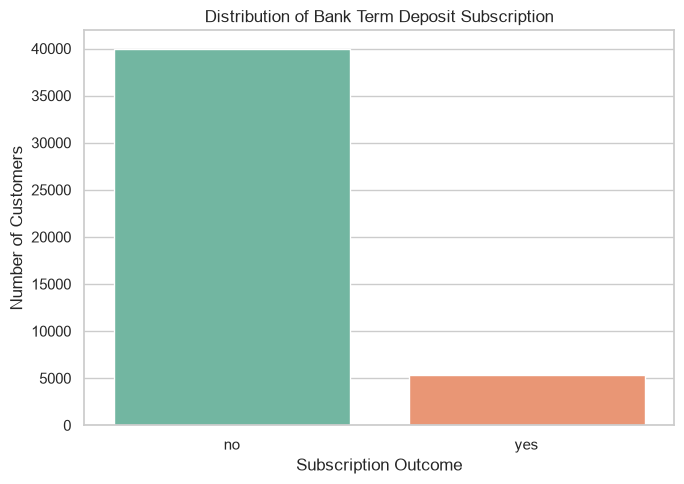

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="y",
    hue="y",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Bank Term Deposit Subscription")
plt.xlabel("Subscription Outcome")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [20]:
# Count unknown values in each column
unknown_counts = (df == "unknown").sum()

unknown_summary = pd.DataFrame({
    "Unknown Count": unknown_counts,
    "Unknown Percentage": (unknown_counts / len(df)) * 100
})

display(unknown_summary[unknown_summary["Unknown Count"] > 0])

,Unknown Count,Unknown Percentage
job,288,0.637013
education,1857,4.107407
contact,13020,28.798301
poutcome,36959,81.747805


In [21]:
# Numerical summary
display(df[numerical_features].describe().T)

# Skewness
skewness = df[numerical_features].skew()

skewness_summary = pd.DataFrame({
    "Skewness": skewness
})

display(skewness_summary)

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


,Skewness
age,0.684818
balance,8.360308
day,0.093079
duration,3.144318
campaign,4.898650
pdays,2.615715
previous,41.846454


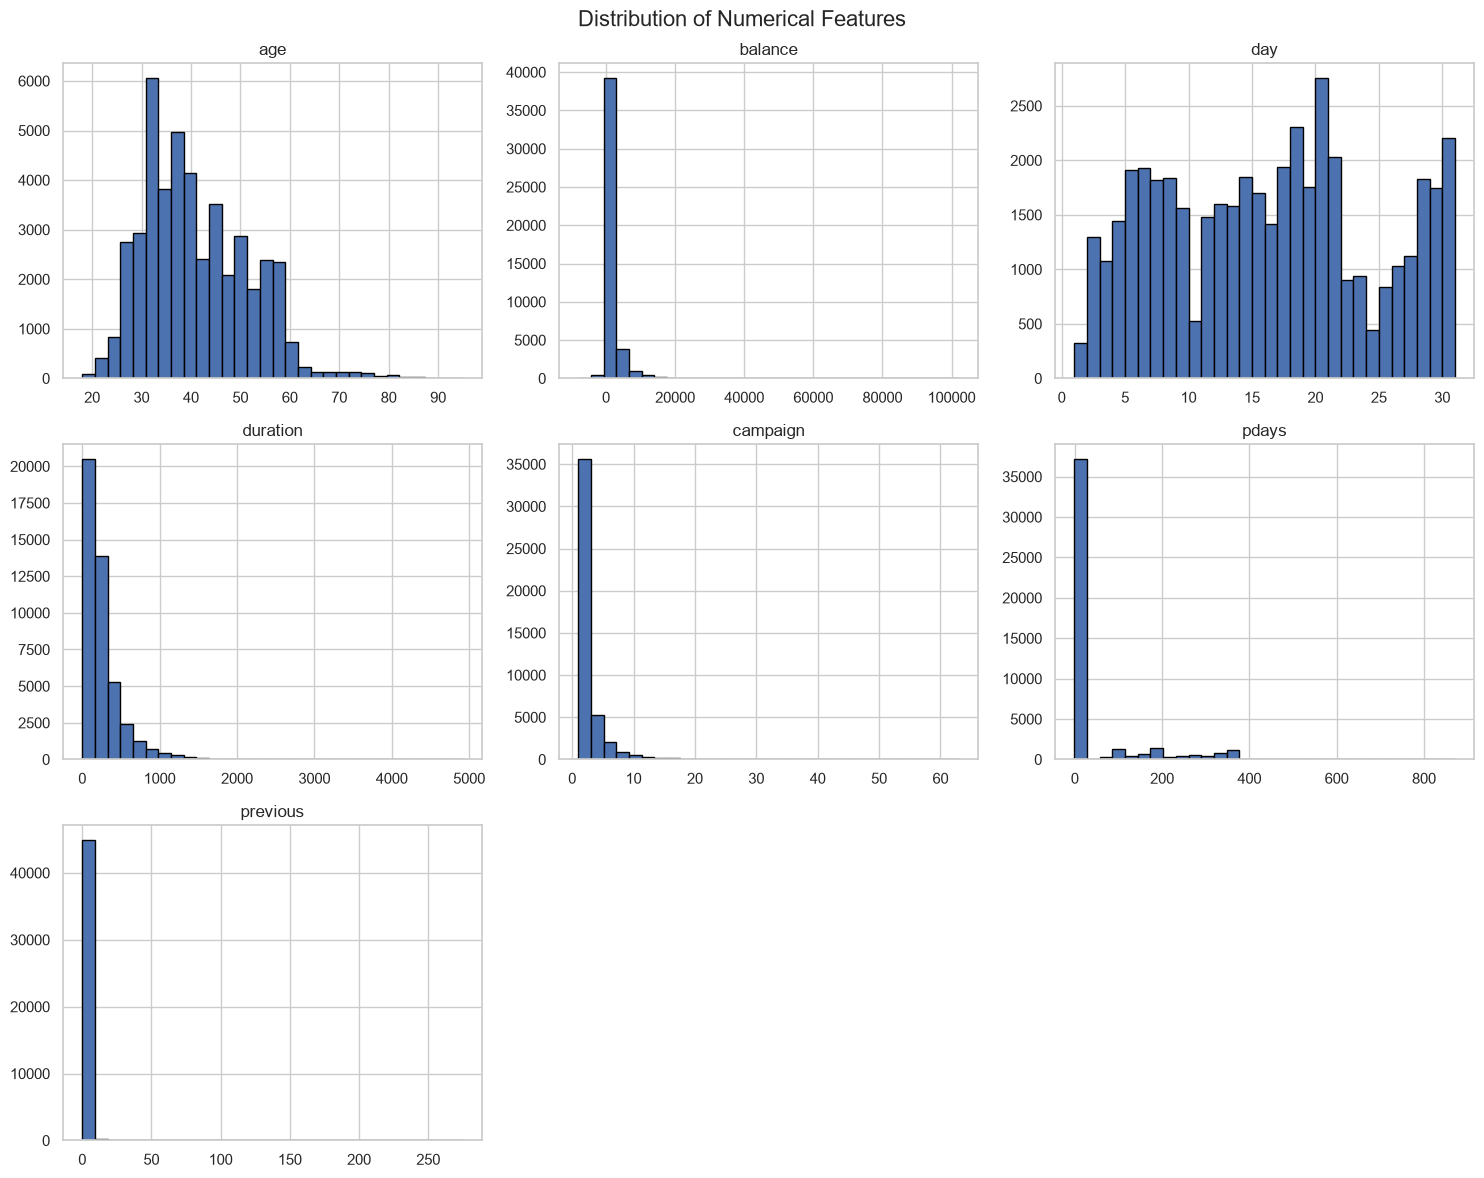

In [22]:
df[numerical_features].hist(
    figsize=(15, 12),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

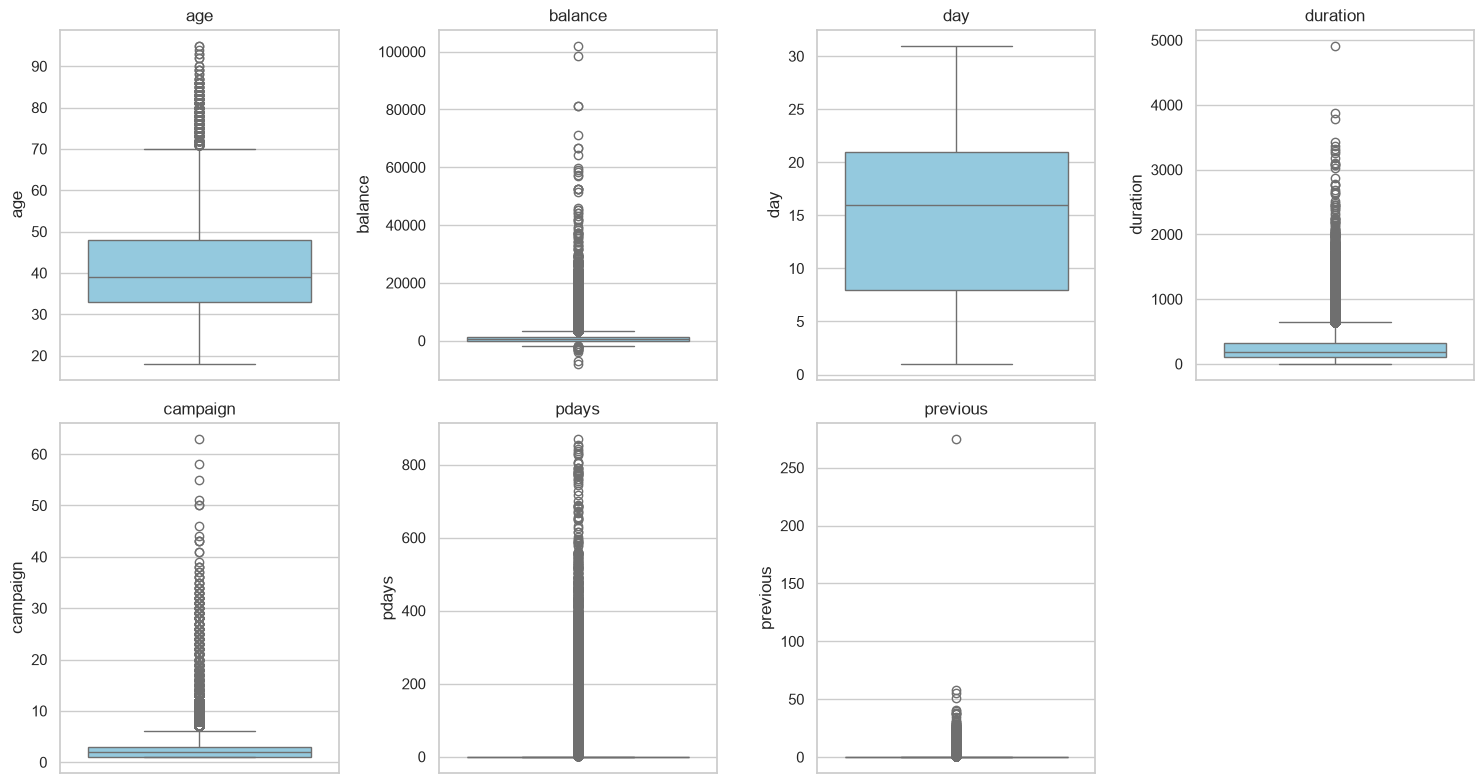

In [23]:
plt.figure(figsize=(15, 8))

for i, column in enumerate(numerical_features, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[column], color="skyblue")
    plt.title(column)

plt.tight_layout()
plt.show()

In [24]:
print("Number of records where pdays = -1:")
print((df["pdays"] == -1).sum())

print("\nPercentage of records where pdays = -1:")
print(round((df["pdays"] == -1).mean() * 100, 2), "%")

Number of records where pdays = -1:
36954

Percentage of records where pdays = -1:
81.74 %


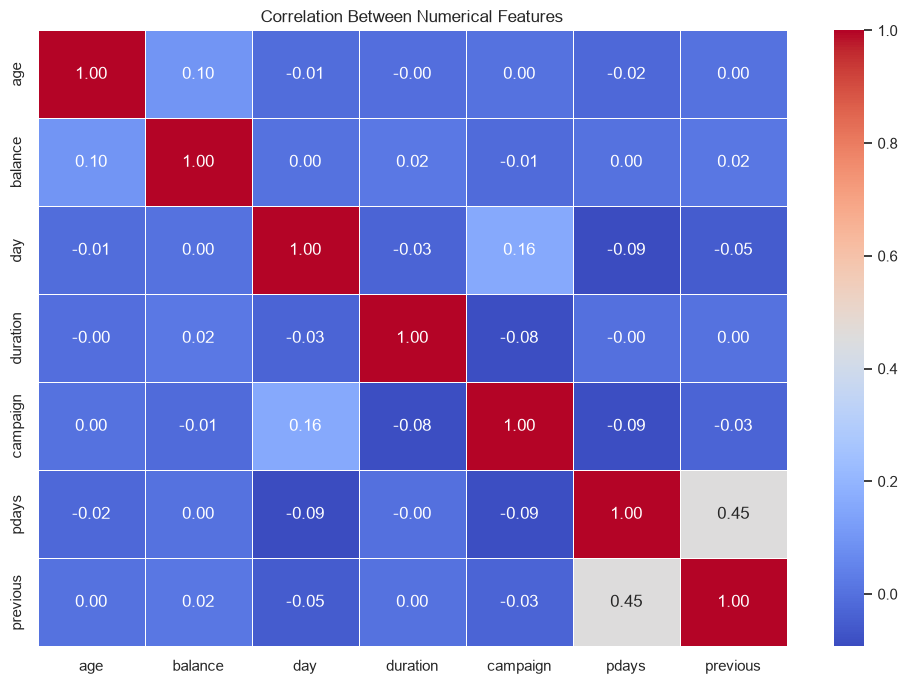

In [25]:
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Numerical Features")
plt.tight_layout()
plt.show()

In [26]:
categorical_features_without_target = [
    col for col in categorical_features if col != "y"
]

for column in categorical_features_without_target:
    print(f"\nFeature: {column}")
    display(df[column].value_counts().head(10))


Feature: job


job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
Name: count, dtype: int64


Feature: marital


marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


Feature: education


...

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


Feature: month


month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
Name: count, dtype: int64


Feature: poutcome


poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [27]:
df["previously_contacted"] = (df["pdays"] != -1).astype(int)

display(df["previously_contacted"].value_counts())

previously_contacted
0    36954
1     8257
Name: count, dtype: int64

In [28]:
outlier_results = []

for column in numerical_features:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_results.append({
        "Feature": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary.round(2))

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,age,10.5,70.5,487,1.08
1,balance,-1962.0,3462.0,4729,10.46
2,day,-11.5,40.5,0,0.00
3,duration,-221.0,643.0,3235,7.16
4,campaign,-2.0,6.0,3064,6.78
5,pdays,-1.0,-1.0,8257,18.26
6,previous,0.0,0.0,8257,18.26


In [29]:
pdays_outcome_table = pd.crosstab(
    df["pdays"] == -1,
    df["poutcome"],
    margins=True
)

display(pdays_outcome_table)

poutcome,failure,other,success,unknown,All
pdays,,,,,
False,4901,1840,1511,5,8257
True,0,0,0,36954,36954
All,4901,1840,1511,36959,45211


In [30]:
print("Distribution of previous contacts:")

display(
    df["previous"].value_counts()
    .sort_index()
    .head(20)
)

print("Number of records with previous > 0:")
print((df["previous"] > 0).sum())

Distribution of previous contacts:


previous
0     36954
1      2772
2      2106
3      1142
4       714
5       459
6       277
7       205
8       129
9        92
10       67
11       65
12       44
13       38
14       19
15       20
16       13
17       15
18        6
19       11
Name: count, dtype: int64

Number of records with previous > 0:
8257


In [31]:
for column in ["job", "education", "contact", "poutcome"]:

    print(f"\nTarget distribution for {column}:")

    display(
        pd.crosstab(
            df[column],
            df["y"],
            normalize="index"
        ).round(3)
    )


Target distribution for job:


y,no,yes
job,,
admin.,0.878,0.122
blue-collar,0.927,0.073
entrepreneur,0.917,0.083
housemaid,0.912,0.088
management,0.862,0.138
retired,0.772,0.228
self-employed,0.882,0.118
services,0.911,0.089
student,0.713,0.287



Target distribution for education:


y,no,yes
education,,
primary,0.914,0.086
secondary,0.894,0.106
tertiary,0.850,0.150
unknown,0.864,0.136



Target distribution for contact:


y,no,yes
contact,,
cellular,0.851,0.149
telephone,0.866,0.134
unknown,0.959,0.041



Target distribution for poutcome:


y,no,yes
poutcome,,
failure,0.874,0.126
other,0.833,0.167
success,0.353,0.647
unknown,0.908,0.092


In [32]:
df["previously_contacted"] = (
    df["pdays"] != -1
).astype(int)

display(
    df["previously_contacted"].value_counts()
)

previously_contacted
0    36954
1     8257
Name: count, dtype: int64

In [33]:
print("Distribution of previous contacts:")

display(
    df["previous"].value_counts()
    .sort_index()
    .head(20)
)

print("Number of records with previous > 0:")
print((df["previous"] > 0).sum())

Distribution of previous contacts:


previous
0     36954
1      2772
2      2106
3      1142
4       714
5       459
6       277
7       205
8       129
9        92
10       67
11       65
12       44
13       38
14       19
15       20
16       13
17       15
18        6
19       11
Name: count, dtype: int64

Number of records with previous > 0:
8257


In [34]:
for column in ["job", "education", "contact", "poutcome"]:

    print(f"\nTarget distribution for {column}:")

    display(
        pd.crosstab(
            df[column],
            df["y"],
            normalize="index"
        ).round(3)
    )


Target distribution for job:


y,no,yes
job,,
admin.,0.878,0.122
blue-collar,0.927,0.073
entrepreneur,0.917,0.083
housemaid,0.912,0.088
management,0.862,0.138
retired,0.772,0.228
self-employed,0.882,0.118
services,0.911,0.089
student,0.713,0.287



Target distribution for education:


y,no,yes
education,,
primary,0.914,0.086
secondary,0.894,0.106
tertiary,0.850,0.150
unknown,0.864,0.136



Target distribution for contact:


y,no,yes
contact,,
cellular,0.851,0.149
telephone,0.866,0.134
unknown,0.959,0.041



Target distribution for poutcome:


y,no,yes
poutcome,,
failure,0.874,0.126
other,0.833,0.167
success,0.353,0.647
unknown,0.908,0.092


In [35]:
df_experiment = df.copy()

print("Original dataset shape:", df.shape)
print("Experiment dataset shape:", df_experiment.shape)

Original dataset shape: (45211, 18)
Experiment dataset shape: (45211, 18)


In [36]:
df_experiment["previously_contacted"] = (
    df_experiment["pdays"] != -1
).astype(int)

display(
    df_experiment[
        ["pdays", "previous", "previously_contacted"]
    ].head(10)
)

,pdays,previous,previously_contacted
0,-1,0,0
1,-1,0,0
2,-1,0,0
3,-1,0,0
4,-1,0,0
5,-1,0,0
6,-1,0,0
7,-1,0,0
8,-1,0,0
9,-1,0,0


In [37]:
X = df_experiment.drop(columns=["y"])
y = df_experiment["y"].map({
    "no": 0,
    "yes": 1
})

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

display(y.value_counts())

Predictor shape: (45211, 17)
Target shape: (45211,)


y
0    39922
1     5289
Name: count, dtype: int64

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training predictors:", X_train.shape)
print("Testing predictors:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).round(3))

Training predictors: (36168, 17)
Testing predictors: (9043, 17)

Training target distribution:


y
0    0.883
1    0.117
Name: proportion, dtype: float64


Testing target distribution:


y
0    0.883
1    0.117
Name: proportion, dtype: float64

In [39]:
# Copy the existing predictors
X_model = X.copy()

# Exclude duration to avoid using information
# that is only available after the current call
X_model = X_model.drop(columns=["duration"])

print("Predictor columns:")
print(X_model.columns.tolist())

print("\nPredictor shape:", X_model.shape)

Predictor columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'previously_contacted']

Predictor shape: (45211, 16)


In [40]:
numerical_columns = X_model.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_model.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

print("\nNumber of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

Numerical columns:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'previously_contacted']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Number of numerical columns: 7
Number of categorical columns: 9


In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [42]:
# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both transformations
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [43]:
# Fit and transform training data
X_train_processed = preprocessor.fit_transform(X_train.drop(columns=["duration"]))

# Transform testing data using the fitted pipeline
X_test_processed = preprocessor.transform(X_test.drop(columns=["duration"]))

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (36168, 51)
Testing data after preprocessing: (9043, 51)


In [44]:
print("Training data type:", type(X_train_processed))
print("Testing data type:", type(X_test_processed))

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

print("Any missing values in training:",
      np.isnan(X_train_processed.toarray()).sum()
      if hasattr(X_train_processed, "toarray")
      else np.isnan(X_train_processed).sum())

print("Any missing values in testing:",
      np.isnan(X_test_processed.toarray()).sum()
      if hasattr(X_test_processed, "toarray")
      else np.isnan(X_test_processed).sum())

Training data type: <class 'numpy.ndarray'>
Testing data type: <class 'numpy.ndarray'>
Training shape: (36168, 51)
Testing shape: (9043, 51)
Any missing values in training: 0
Any missing values in testing: 0


In [45]:
# Exclude duration to prevent data leakage
X_model = X.drop(columns=["duration"])

print("Final predictor columns:")
print(X_model.columns.tolist())

print("\nFinal predictor shape:", X_model.shape)

Final predictor columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'previously_contacted']

Final predictor shape: (45211, 16)


In [46]:
import pandas as pd
import numpy as np

# Reload the original dataset
df_phase7 = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# Select numerical features
numerical_features = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

# Calculate skewness
skewness_results = pd.DataFrame({
    "Feature": numerical_features,
    "Skewness": [
        df_phase7[col].skew()
        for col in numerical_features
    ]
})

print("Skewness of numerical features:")
display(skewness_results.round(3))

Skewness of numerical features:


,Feature,Skewness
0,age,0.685
1,balance,8.360
2,day,0.093
3,duration,3.144
4,campaign,4.899
5,pdays,2.616
6,previous,41.846


In [47]:
# Create a separate copy for transformation experiments
df_transformed = df_phase7.copy()

# Signed log transformation for balance
df_transformed["balance_log"] = (
    np.sign(df_transformed["balance"]) *
    np.log1p(np.abs(df_transformed["balance"]))
)

# Log transformation for non-negative features
df_transformed["campaign_log"] = np.log1p(
    df_transformed["campaign"]
)

df_transformed["previous_log"] = np.log1p(
    df_transformed["previous"]
)

df_transformed["duration_log"] = np.log1p(
    df_transformed["duration"]
)

# Compare original and transformed skewness
comparison = pd.DataFrame({
    "Feature": [
        "balance",
        "campaign",
        "previous",
        "duration"
    ],

    "Original Skewness": [
        df_phase7["balance"].skew(),
        df_phase7["campaign"].skew(),
        df_phase7["previous"].skew(),
        df_phase7["duration"].skew()
    ],

    "Transformed Skewness": [
        df_transformed["balance_log"].skew(),
        df_transformed["campaign_log"].skew(),
        df_transformed["previous_log"].skew(),
        df_transformed["duration_log"].skew()
    ]
})

display(comparison.round(3))

,Feature,Original Skewness,Transformed Skewness
0,balance,8.360,-1.583
1,campaign,4.899,1.326
2,previous,41.846,2.516
3,duration,3.144,-0.454


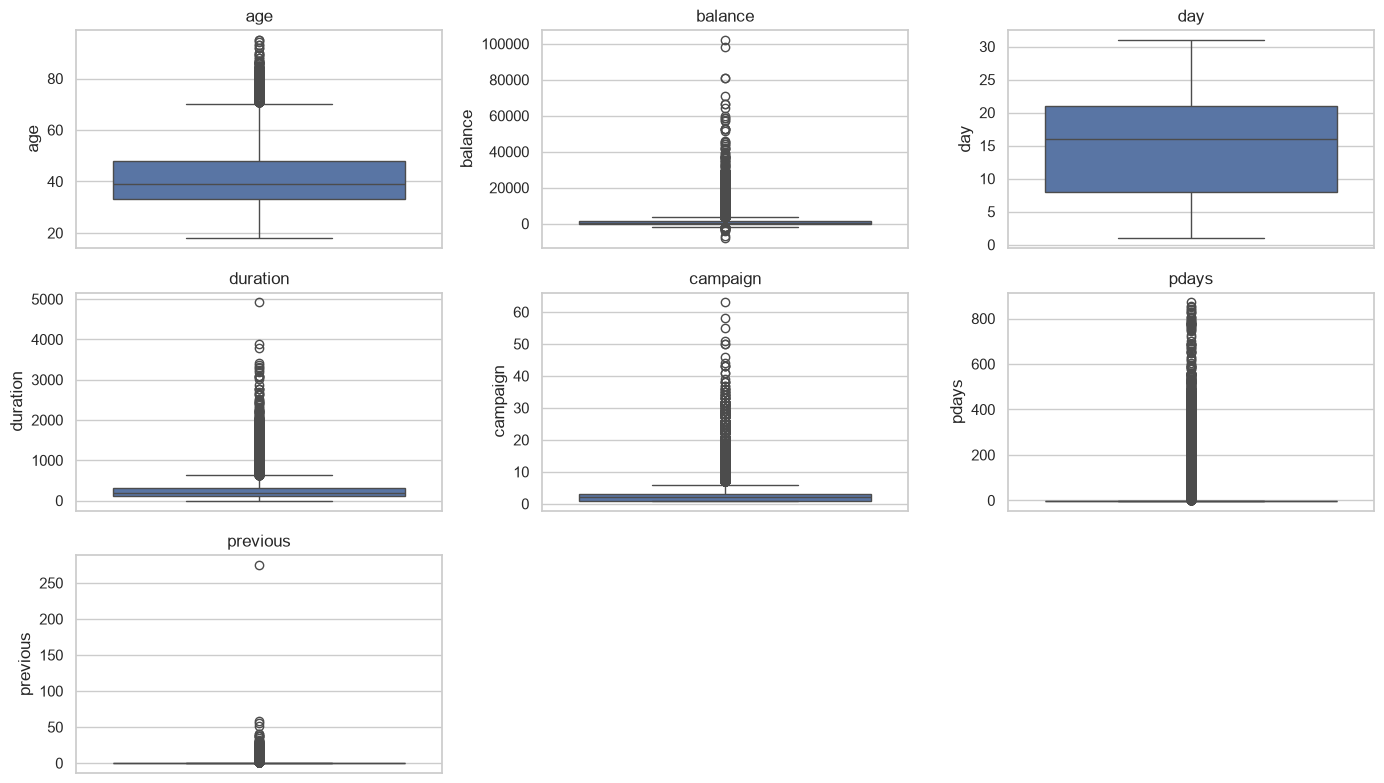

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical features
numerical_features = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

# Create boxplots
plt.figure(figsize=(14, 8))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_phase7[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [49]:
# Create a separate copy for the IQR experiment
df_capped = df_phase7.copy()

# Features selected for the capping experiment
features_to_cap = [
    "age",
    "balance",
    "duration",
    "campaign"
]

results = []

for col in features_to_cap:

    # Calculate IQR boundaries
    Q1 = df_phase7[col].quantile(0.25)
    Q3 = df_phase7[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count observations outside the boundaries
    outlier_count = (
        (df_phase7[col] < lower_bound) |
        (df_phase7[col] > upper_bound)
    ).sum()

    # Apply capping to the experimental copy
    df_capped[col] = df_phase7[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    results.append({
        "Feature": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers Capped": outlier_count,
        "Original Min": df_phase7[col].min(),
        "Original Max": df_phase7[col].max(),
        "Capped Min": df_capped[col].min(),
        "Capped Max": df_capped[col].max()
    })

capping_results = pd.DataFrame(results)

display(capping_results.round(2))

,Feature,Lower Bound,Upper Bound,Outliers Capped,Original Min,Original Max,Capped Min,Capped Max
0,age,10.5,70.5,487,18,95,18.0,70.5
1,balance,-1962.0,3462.0,4729,-8019,102127,-1962.0,3462.0
2,duration,-221.0,643.0,3235,0,4918,0.0,643.0
3,campaign,-2.0,6.0,3064,1,63,1.0,6.0


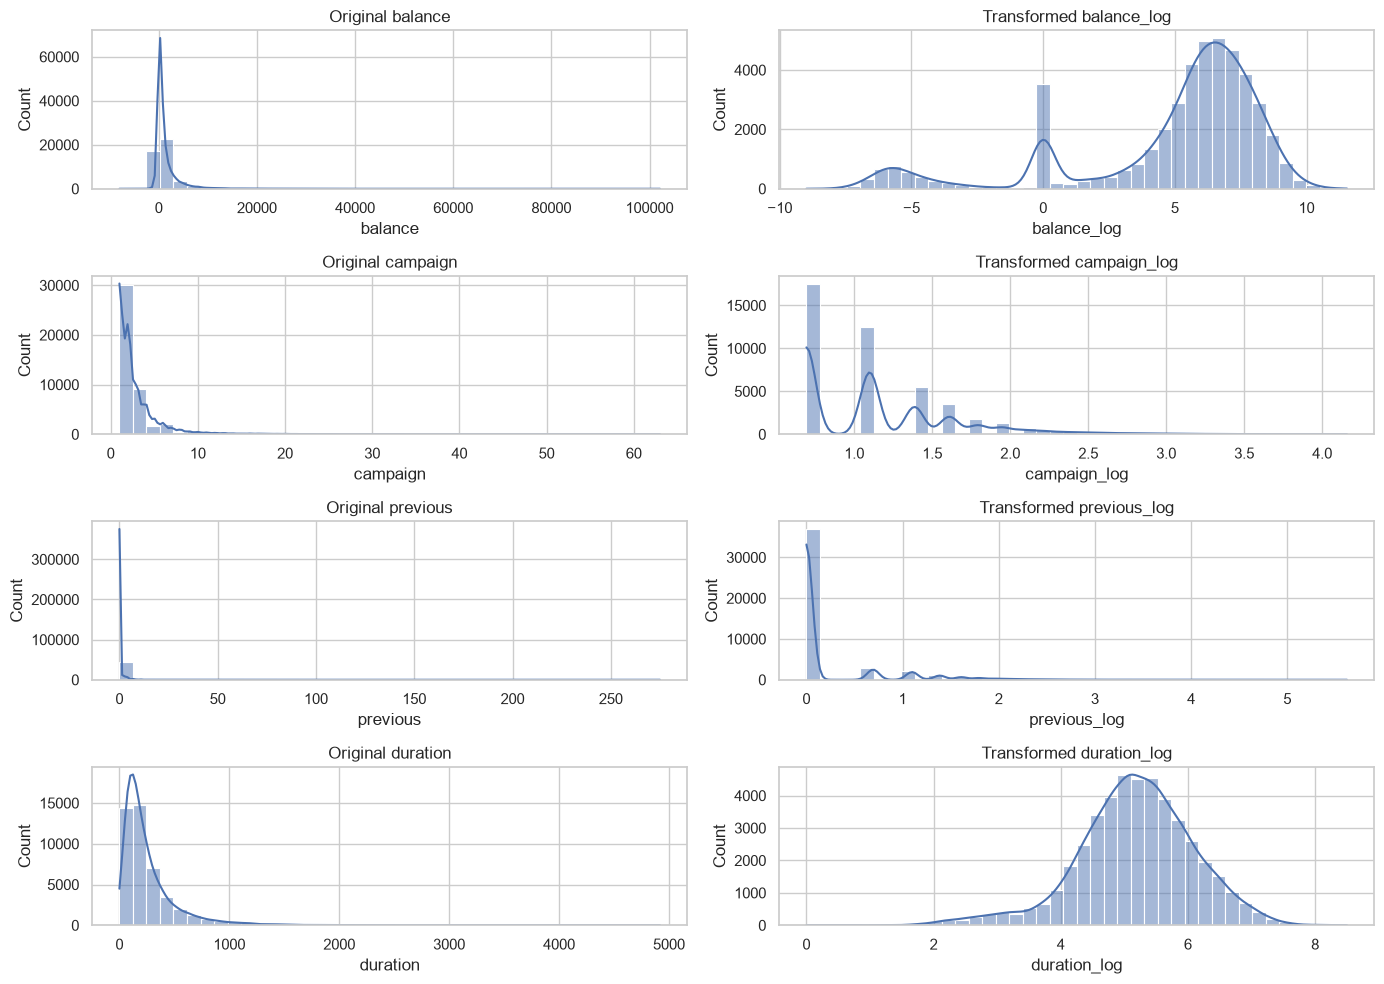

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compare original and transformed distributions
features_to_compare = [
    ("balance", "balance_log"),
    ("campaign", "campaign_log"),
    ("previous", "previous_log"),
    ("duration", "duration_log")
]

plt.figure(figsize=(14, 10))

for i, (original, transformed) in enumerate(
    features_to_compare, 1
):
    # Original distribution
    plt.subplot(4, 2, 2*i - 1)
    sns.histplot(
        df_phase7[original],
        bins=40,
        kde=True
    )
    plt.title(f"Original {original}")

    # Transformed distribution
    plt.subplot(4, 2, 2*i)
    sns.histplot(
        df_transformed[transformed],
        bins=40,
        kde=True
    )
    plt.title(f"Transformed {transformed}")

plt.tight_layout()
plt.show()

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reload the original dataset
df_phase8 = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# Create engineered feature
df_phase8["previously_contacted"] = (
    df_phase8["pdays"] != -1
).astype(int)

# Select numerical predictors, excluding duration
numerical_features = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous",
    "previously_contacted"
]

# Calculate correlation matrix
correlation_matrix = df_phase8[
    numerical_features
].corr()

print("Numerical Feature Correlation Matrix:")
display(correlation_matrix.round(2))

Numerical Feature Correlation Matrix:


,age,balance,day,campaign,pdays,previous,previously_contacted
age,1.00,0.10,-0.01,0.00,-0.02,0.00,0.00
balance,0.10,1.00,0.00,-0.01,0.00,0.02,0.03
day,-0.01,0.00,1.00,0.16,-0.09,-0.05,-0.09
campaign,0.00,-0.01,0.16,1.00,-0.09,-0.03,-0.11
pdays,-0.02,0.00,-0.09,-0.09,1.00,0.45,0.87
previous,0.00,0.02,-0.05,-0.03,0.45,1.00,0.53
previously_contacted,0.00,0.03,-0.09,-0.11,0.87,0.53,1.00


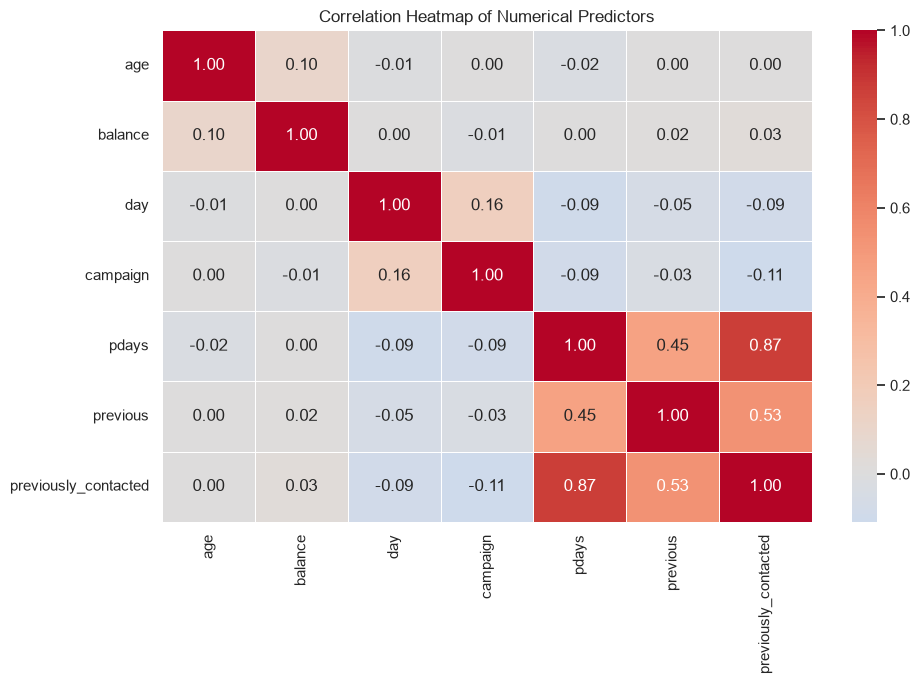

In [53]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Predictors")
plt.tight_layout()
plt.show()

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif

# Reload original dataset
df_mi = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# Create engineered feature
df_mi["previously_contacted"] = (
    df_mi["pdays"] != -1
).astype(int)

# Separate predictors and target
X_mi = df_mi.drop(columns=["y", "duration"])

y_mi = df_mi["y"].map({
    "no": 0,
    "yes": 1
})

# Identify numerical and categorical features
numerical_columns = X_mi.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = X_mi.select_dtypes(
    exclude=["number"]
).columns.tolist()

# Split dataset
X_train_mi, X_test_mi, y_train_mi, y_test_mi = train_test_split(
    X_mi,
    y_mi,
    test_size=0.20,
    random_state=42,
    stratify=y_mi
)

# Encode categorical variables
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_encoded = X_train_mi.copy()

X_train_encoded[categorical_columns] = encoder.fit_transform(
    X_train_mi[categorical_columns]
)

# Identify discrete features
discrete_mask = [
    col in categorical_columns or col == "previously_contacted"
    for col in X_train_encoded.columns
]

# Calculate Mutual Information
mi_scores = mutual_info_classif(
    X_train_encoded,
    y_train_mi,
    discrete_features=discrete_mask,
    random_state=42
)

# Display results
mi_results = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Mutual Information": mi_scores
}).sort_values(
    by="Mutual Information",
    ascending=False
)

display(mi_results.round(4))

,Feature,Mutual Information
14,poutcome,0.0291
12,pdays,0.0256
10,month,0.0240
5,balance,0.0214
8,contact,0.0134
15,previously_contacted,0.0115
13,previous,0.0113
0,age,0.0104
6,housing,0.0097
1,job,0.0085


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

# Create preprocessing pipeline for PCA
pca_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    sparse_threshold=0
)

# Fit preprocessing on training data only
X_train_pca_ready = pca_preprocessor.fit_transform(
    X_train_mi
)

# Transform test data using the fitted preprocessor
X_test_pca_ready = pca_preprocessor.transform(
    X_test_mi
)

print("Training data before PCA:", X_train_pca_ready.shape)
print("Testing data before PCA:", X_test_pca_ready.shape)

Training data before PCA: (36168, 51)
Testing data before PCA: (9043, 51)


In [56]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fit PCA using training data only
pca = PCA()

X_train_pca = pca.fit_transform(X_train_pca_ready)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

# Find components needed for 90% and 95% variance
components_90 = np.argmax(
    cumulative_variance >= 0.90
) + 1

components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print("Original number of features:", X_train_pca_ready.shape[1])

print("Components for 90% variance:", components_90)

print("Components for 95% variance:", components_95)

print(
    "Variance retained with 90% components:",
    round(cumulative_variance[components_90 - 1], 4)
)

print(
    "Variance retained with 95% components:",
    round(cumulative_variance[components_95 - 1], 4)
)

Original number of features: 51
Components for 90% variance: 17
Components for 95% variance: 23
Variance retained with 90% components: 0.9035
Variance retained with 95% components: 0.9511


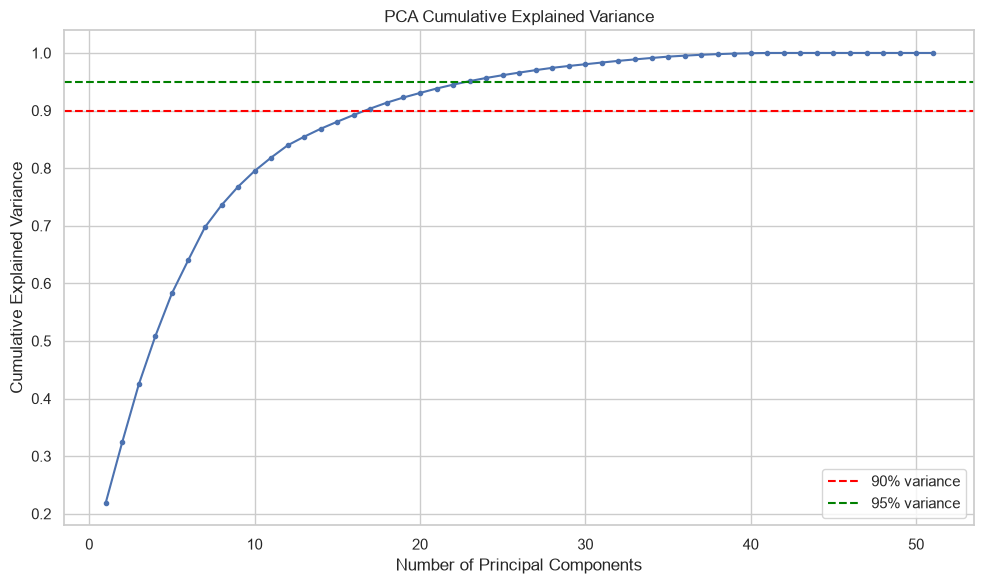

In [57]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    markersize=3
)

plt.axhline(
    y=0.90,
    color="red",
    linestyle="--",
    label="90% variance"
)

plt.axhline(
    y=0.95,
    color="green",
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [58]:
from sklearn.decomposition import PCA

# PCA retaining 90% variance
pca_90 = PCA(n_components=0.90)

X_train_pca_90 = pca_90.fit_transform(
    X_train_pca_ready
)

X_test_pca_90 = pca_90.transform(
    X_test_pca_ready
)

# PCA retaining 95% variance
pca_95 = PCA(n_components=0.95)

X_train_pca_95 = pca_95.fit_transform(
    X_train_pca_ready
)

X_test_pca_95 = pca_95.transform(
    X_test_pca_ready
)

# Display results
print("Original training shape:", X_train_pca_ready.shape)
print("Original testing shape:", X_test_pca_ready.shape)

print("\n90% PCA:")
print("Training shape:", X_train_pca_90.shape)
print("Testing shape:", X_test_pca_90.shape)
print("Variance retained:", round(pca_90.explained_variance_ratio_.sum(), 4))

print("\n95% PCA:")
print("Training shape:", X_train_pca_95.shape)
print("Testing shape:", X_test_pca_95.shape)
print("Variance retained:", round(pca_95.explained_variance_ratio_.sum(), 4))

Original training shape: (36168, 51)
Original testing shape: (9043, 51)

90% PCA:
Training shape: (36168, 17)
Testing shape: (9043, 17)
Variance retained: 0.9035

95% PCA:
Training shape: (36168, 23)
Testing shape: (9043, 23)
Variance retained: 0.9511


In [59]:
# Select the top 10 features based on Mutual Information
top_10_features = mi_results.head(10)["Feature"].tolist()

print("Selected top 10 features:")
print(top_10_features)

print("\nOriginal number of features:", len(mi_results))
print("Selected number of features:", len(top_10_features))

print("\nReduced training shape:")
print(X_train_mi[top_10_features].shape)

print("\nReduced testing shape:")
print(X_test_mi[top_10_features].shape)

Selected top 10 features:
['poutcome', 'pdays', 'month', 'balance', 'contact', 'previously_contacted', 'previous', 'age', 'housing', 'job']

Original number of features: 16
Selected number of features: 10

Reduced training shape:
(36168, 10)

Reduced testing shape:
(9043, 10)


In [60]:
# Examine original training class distribution

train_class_counts = y_train_mi.value_counts().sort_index()

train_class_percentages = (
    y_train_mi.value_counts(normalize=True)
    .sort_index() * 100
)

class_distribution = pd.DataFrame({
    "Class": ["No (0)", "Yes (1)"],
    "Count": train_class_counts.values,
    "Percentage": train_class_percentages.values
})

display(class_distribution.round(2))

print("Total training records:", len(y_train_mi))
print(
    "Class imbalance ratio:",
    round(
        train_class_counts.loc[0] /
        train_class_counts.loc[1],
        2
    ),
    ": 1"
)

,Class,Count,Percentage
0,No (0),31937,88.3
1,Yes (1),4231,11.7


Total training records: 36168
Class imbalance ratio: 7.55 : 1


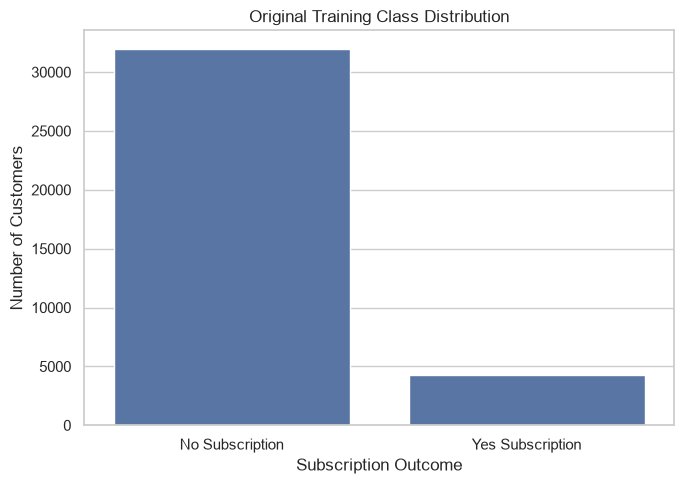

In [61]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train_mi.map({
        0: "No Subscription",
        1: "Yes Subscription"
    })
)

plt.title("Original Training Class Distribution")
plt.xlabel("Subscription Outcome")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [62]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Identify the classes
classes = np.array([0, 1])

# Calculate balanced class weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_mi
)

# Convert results into a dictionary
class_weights = dict(zip(classes, weights))

print("Class weights:")
print(class_weights)

print("\nClass 0 weight:", round(class_weights[0], 4))
print("Class 1 weight:", round(class_weights[1], 4))

Class weights:
{np.int64(0): np.float64(0.5662397845758838), np.int64(1): np.float64(4.27416686362562)}

Class 0 weight: 0.5662
Class 1 weight: 4.2742


In [63]:
%pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.


In [64]:
from imblearn.over_sampling import RandomOverSampler

# Create the oversampling object
ros = RandomOverSampler(
    sampling_strategy="auto",
    random_state=42
)

# Apply oversampling to training data only
X_train_ros, y_train_ros = ros.fit_resample(
    X_train_mi,
    y_train_mi
)

# Display the new class distribution
print("Original training distribution:")
print(y_train_mi.value_counts().sort_index())

print("\nAfter Random Oversampling:")
print(y_train_ros.value_counts().sort_index())

print("\nOriginal training shape:", X_train_mi.shape)
print("Oversampled training shape:", X_train_ros.shape)

Original training distribution:
y
0    31937
1     4231
Name: count, dtype: int64

After Random Oversampling:
y
0    31937
1    31937
Name: count, dtype: int64

Original training shape: (36168, 16)
Oversampled training shape: (63874, 16)


In [65]:
print("X_train_mi shape:", X_train_mi.shape)

print("\nColumns in X_train_mi:")
print(X_train_mi.columns.tolist())

print("\nTop 10 selected features:")
print(top_10_features)

X_train_mi shape: (36168, 16)

Columns in X_train_mi:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'previously_contacted']

Top 10 selected features:
['poutcome', 'pdays', 'month', 'balance', 'contact', 'previously_contacted', 'previous', 'age', 'housing', 'job']


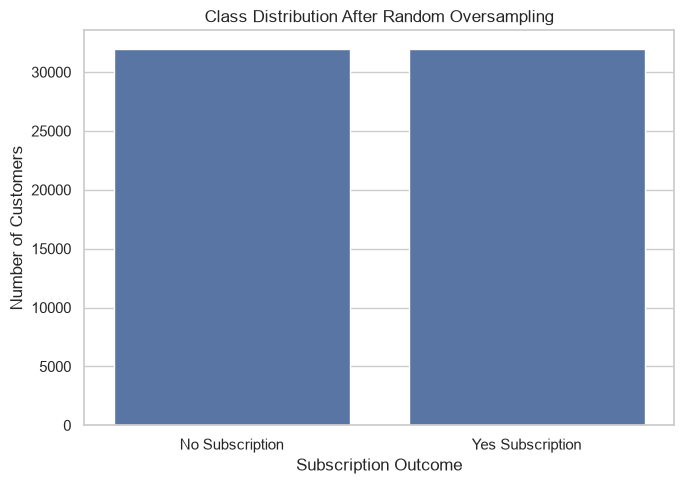

In [66]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train_ros.map({
        0: "No Subscription",
        1: "Yes Subscription"
    })
)

plt.title("Class Distribution After Random Oversampling")
plt.xlabel("Subscription Outcome")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [67]:
from imblearn.under_sampling import RandomUnderSampler

# Create undersampling object
rus = RandomUnderSampler(
    sampling_strategy="auto",
    random_state=42
)

# Apply undersampling to training data only
X_train_rus, y_train_rus = rus.fit_resample(
    X_train_mi,
    y_train_mi
)

# Display class distribution
print("Original training distribution:")
print(y_train_mi.value_counts().sort_index())

print("\nAfter Random Undersampling:")
print(y_train_rus.value_counts().sort_index())

print("\nOriginal training shape:", X_train_mi.shape)
print("Undersampled training shape:", X_train_rus.shape)

Original training distribution:
y
0    31937
1     4231
Name: count, dtype: int64

After Random Undersampling:
y
0    4231
1    4231
Name: count, dtype: int64

Original training shape: (36168, 16)
Undersampled training shape: (8462, 16)


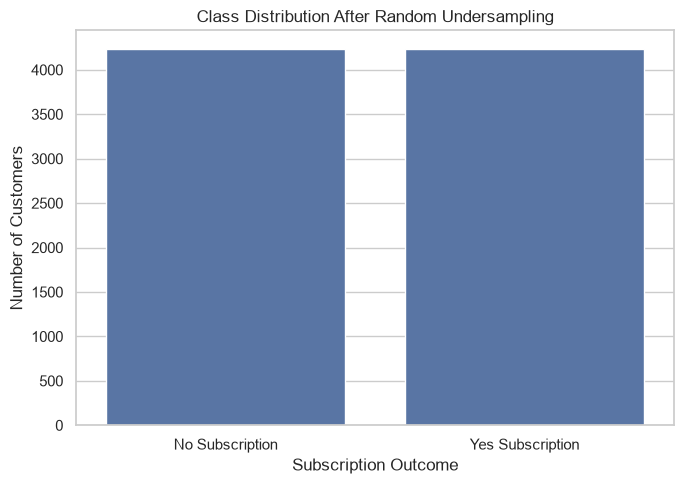

In [68]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train_rus.map({
        0: "No Subscription",
        1: "Yes Subscription"
    })
)

plt.title("Class Distribution After Random Undersampling")
plt.xlabel("Subscription Outcome")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [69]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [70]:
from imblearn.over_sampling import SMOTENC

# Identify categorical columns
categorical_features = X_train_mi.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:")
print(len(categorical_features))

print("\nTraining data shape:")
print(X_train_mi.shape)

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Number of categorical features:
9

Training data shape:
(36168, 16)


In [71]:
from imblearn.over_sampling import SMOTENC

# Create SMOTENC object
smotenc = SMOTENC(
    categorical_features=categorical_features,
    sampling_strategy="auto",
    random_state=42
)

# Apply SMOTENC to training data only
X_train_smote, y_train_smote = smotenc.fit_resample(
    X_train_mi,
    y_train_mi
)

# Display class distributions
print("Original training distribution:")
print(y_train_mi.value_counts().sort_index())

print("\nAfter SMOTENC:")
print(y_train_smote.value_counts().sort_index())

# Display dataset shapes
print("\nOriginal training shape:", X_train_mi.shape)
print("SMOTENC training shape:", X_train_smote.shape)

# Check categorical feature values
print("\nCategorical feature data types:")
print(X_train_smote[categorical_features].dtypes)

Original training distribution:
y
0    31937
1     4231
Name: count, dtype: int64

After SMOTENC:
y
0    31937
1    31937
Name: count, dtype: int64

Original training shape: (36168, 16)
SMOTENC training shape: (63874, 16)

Categorical feature data types:
job          str
marital      str
education    str
default      str
housing      str
loan         str
contact      str
month        str
poutcome     str
dtype: object


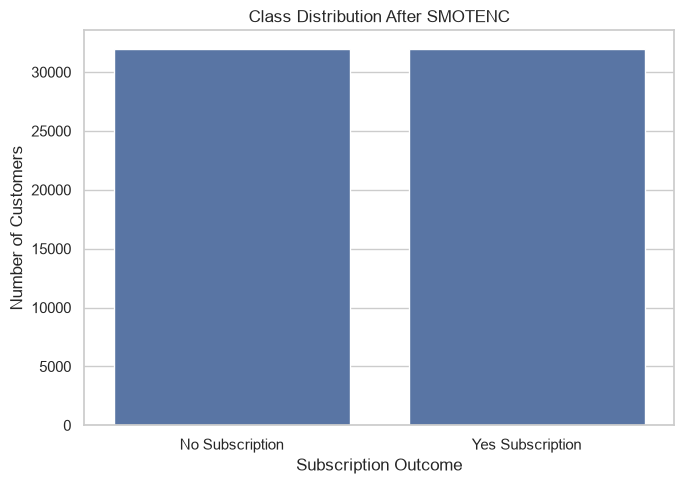

In [72]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train_smote.map({
        0: "No Subscription",
        1: "Yes Subscription"
    })
)

plt.title("Class Distribution After SMOTENC")
plt.xlabel("Subscription Outcome")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [73]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTENC

# Copy original training data
X_train_scaled = X_train_mi.copy()

# Identify numerical columns
numerical_features = X_train_scaled.select_dtypes(
    include=["number"]
).columns.tolist()

# Create scaler
scaler_smote = StandardScaler()

# Fit scaler using training data only
X_train_scaled[numerical_features] = scaler_smote.fit_transform(
    X_train_scaled[numerical_features]
)

print("Numerical features:")
print(numerical_features)

print("\nScaled training shape:")
print(X_train_scaled.shape)

print("\nScaled numerical summary:")
display(X_train_scaled[numerical_features].describe().round(2))

Numerical features:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'previously_contacted']

Scaled training shape:
(36168, 16)

Scaled numerical summary:


,age,balance,day,campaign,pdays,previous,previously_contacted
count,36168.00,36168.00,36168.00,36168.00,36168.00,36168.00,36168.00
mean,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.15,-3.06,-1.78,-0.57,-0.41,-0.24,-0.47
25%,-0.74,-0.42,-0.94,-0.57,-0.41,-0.24,-0.47
50%,-0.18,-0.30,0.02,-0.25,-0.41,-0.24,-0.47
75%,0.67,0.02,0.62,0.08,-0.41,-0.24,-0.47
max,5.09,32.84,1.82,19.41,8.30,113.93,2.12


In [74]:
smotenc_scaled = SMOTENC(
    categorical_features=categorical_features,
    sampling_strategy="auto",
    random_state=42
)

X_train_smote_scaled, y_train_smote_scaled = (
    smotenc_scaled.fit_resample(
        X_train_scaled,
        y_train_mi
    )
)

print("Class distribution after scaled SMOTENC:")
print(y_train_smote_scaled.value_counts().sort_index())

print("\nScaled SMOTENC training shape:")
print(X_train_smote_scaled.shape)

print("\nMissing values:")
print(X_train_smote_scaled.isna().sum().sum())

Class distribution after scaled SMOTENC:
y
0    31937
1    31937
Name: count, dtype: int64

Scaled SMOTENC training shape:
(63874, 16)

Missing values:
0


In [75]:
comparison_data = {
    "Technique": [
        "Original Training Data",
        "Class Weighting",
        "Random Oversampling",
        "Random Undersampling",
        "SMOTENC",
        "Scaled SMOTENC"
    ],

    "Class 0": [
        y_train_mi.value_counts()[0],
        y_train_mi.value_counts()[0],
        y_train_ros.value_counts()[0],
        y_train_rus.value_counts()[0],
        y_train_smote.value_counts()[0],
        y_train_smote_scaled.value_counts()[0]
    ],

    "Class 1": [
        y_train_mi.value_counts()[1],
        y_train_mi.value_counts()[1],
        y_train_ros.value_counts()[1],
        y_train_rus.value_counts()[1],
        y_train_smote.value_counts()[1],
        y_train_smote_scaled.value_counts()[1]
    ],

    "Total Records": [
        len(y_train_mi),
        len(y_train_mi),
        len(y_train_ros),
        len(y_train_rus),
        len(y_train_smote),
        len(y_train_smote_scaled)
    ]
}

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

,Technique,Class 0,Class 1,Total Records
0,Original Training Data,31937,4231,36168
1,Class Weighting,31937,4231,36168
2,Random Oversampling,31937,31937,63874
3,Random Undersampling,4231,4231,8462
4,SMOTENC,31937,31937,63874
5,Scaled SMOTENC,31937,31937,63874


In [76]:
decision_data = {
    "Technique": [
        "Missing Value Imputation",
        "Duplicate Removal",
        "Unknown Category Handling",
        "Outlier Capping",
        "Log Transformation",
        "Standardisation",
        "One-Hot Encoding",
        "Mutual Information",
        "PCA",
        "Class Weighting",
        "Random Oversampling",
        "Random Undersampling",
        "SMOTENC"
    ],

    "Decision": [
        "Not required initially",
        "Retain cleaning check",
        "Retain categories",
        "Optional",
        "Selective",
        "Retain for scale-sensitive models",
        "Retain",
        "Evaluate",
        "Optional",
        "Candidate",
        "Compare",
        "Compare",
        "Candidate"
    ]
}

decision_df = pd.DataFrame(decision_data)

display(decision_df)

,Technique,Decision
0,Missing Value Imputation,Not required initially
1,Duplicate Removal,Retain cleaning check
2,Unknown Category Handling,Retain categories
3,Outlier Capping,Optional
4,Log Transformation,Selective
5,Standardisation,Retain for scale-sensitive models
6,One-Hot Encoding,Retain
7,Mutual Information,Evaluate
8,PCA,Optional
9,Class Weighting,Candidate


In [77]:
import pandas as pd
import numpy as np

# Reload original dataset
df_final = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# Create a separate working copy
df_final["previously_contacted"] = (
    df_final["pdays"] != -1
).astype(int)

# Define predictors and target
X_final = df_final.drop(
    columns=["y", "duration"]
)

y_final = df_final["y"].map({
    "no": 0,
    "yes": 1
})

print("Original dataset shape:", df_final.shape)
print("Final predictor shape:", X_final.shape)
print("Target shape:", y_final.shape)

print("\nPredictor columns:")
print(X_final.columns.tolist())

print("\nTarget distribution:")
print(y_final.value_counts().sort_index())

Original dataset shape: (45211, 18)
Final predictor shape: (45211, 16)
Target shape: (45211,)

Predictor columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'previously_contacted']

Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64


In [78]:
from sklearn.model_selection import train_test_split

X_train_final, X_test_final, y_train_final, y_test_final = (
    train_test_split(
        X_final,
        y_final,
        test_size=0.20,
        random_state=42,
        stratify=y_final
    )
)

print("Training shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)

print("\nTraining target distribution:")
print(y_train_final.value_counts())

print("\nTesting target distribution:")
print(y_test_final.value_counts())

Training shape: (36168, 16)
Testing shape: (9043, 16)

Training target distribution:
y
0    31937
1     4231
Name: count, dtype: int64

Testing target distribution:
y
0    7985
1    1058
Name: count, dtype: int64


In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify feature types
numerical_final = X_final.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_final = X_final.select_dtypes(
    exclude=["number"]
).columns.tolist()

# Define preprocessing
preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_final),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_final)
    ]
)

# Fit only on training data
X_train_final_processed = preprocessor_final.fit_transform(
    X_train_final
)

# Apply fitted transformations to test data
X_test_final_processed = preprocessor_final.transform(
    X_test_final
)

print("Training processed shape:", X_train_final_processed.shape)
print("Testing processed shape:", X_test_final_processed.shape)

print("\nDuration included:",
      "duration" in X_final.columns)

print("Missing values in training:",
      np.isnan(X_train_final_processed).sum())

print("Missing values in testing:",
      np.isnan(X_test_final_processed).sum())

Training processed shape: (36168, 51)
Testing processed shape: (9043, 51)

Duration included: False
Missing values in training: 0
Missing values in testing: 0


In [80]:
print("Original test shape:", X_test_final.shape)

print("\nOriginal test class distribution:")
print(y_test_final.value_counts().sort_index())

print("\nTest class proportions:")
print(
    (y_test_final.value_counts(normalize=True) * 100)
    .round(2)
)

Original test shape: (9043, 16)

Original test class distribution:
y
0    7985
1    1058
Name: count, dtype: int64

Test class proportions:
y
0    88.3
1    11.7
Name: proportion, dtype: float64


In [81]:
from sklearn.model_selection import train_test_split

X_train_final, X_test_final, y_train_final, y_test_final = (
    train_test_split(
        X_final,
        y_final,
        test_size=0.20,
        random_state=42,
        stratify=y_final
    )
)

print("Training shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)

print("\nTraining target distribution:")
print(y_train_final.value_counts())

print("\nTesting target distribution:")
print(y_test_final.value_counts())

Training shape: (36168, 16)
Testing shape: (9043, 16)

Training target distribution:
y
0    31937
1     4231
Name: count, dtype: int64

Testing target distribution:
y
0    7985
1    1058
Name: count, dtype: int64


In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Identify numerical and categorical features
numerical_final = X_final.select_dtypes(include=["number"]).columns.tolist()
categorical_final = X_final.select_dtypes(exclude=["number"]).columns.tolist()

# Create preprocessing pipeline
preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_final),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_final)
    ]
)

# Fit using training data only
X_train_final_processed = preprocessor_final.fit_transform(X_train_final)

# Transform test data without refitting
X_test_final_processed = preprocessor_final.transform(X_test_final)

print("Numerical features:", len(numerical_final))
print("Categorical features:", len(categorical_final))

print("\nProcessed training shape:", X_train_final_processed.shape)
print("Processed testing shape:", X_test_final_processed.shape)

print("\nMissing values in processed training data:",
      np.isnan(X_train_final_processed).sum())

print("Missing values in processed testing data:",
      np.isnan(X_test_final_processed).sum())

print("\nDuration included:",
      "duration" in X_final.columns)

Numerical features: 7
Categorical features: 9

Processed training shape: (36168, 51)
Processed testing shape: (9043, 51)

Missing values in processed training data: 0
Missing values in processed testing data: 0

Duration included: False


In [83]:
print("Final test set shape:", X_test_final.shape)

print("\nFinal test target distribution:")
print(y_test_final.value_counts().sort_index())

print("\nFinal test target percentages:")
print((y_test_final.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTraining set shape after preprocessing:",
      X_train_final_processed.shape)

print("Testing set shape after preprocessing:",
      X_test_final_processed.shape)

Final test set shape: (9043, 16)

Final test target distribution:
y
0    7985
1    1058
Name: count, dtype: int64

Final test target percentages:
y
0    88.3
1    11.7
Name: proportion, dtype: float64

Training set shape after preprocessing: (36168, 51)
Testing set shape after preprocessing: (9043, 51)
